Импорт библиотек

In [ ]:
import re, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


Скачивание датасета с Kaggle

In [ ]:
from google.colab import userdata
import kagglehub

KAGGLE_API_TOKEN = userdata.get("KAGGLE_API_TOKEN")

path = kagglehub.dataset_download("nelgiriyewithana/mcdonalds-store-reviews")
print("Path:", path)

# Ищем CSV-файлы
csv_files = sorted(glob.glob(f"{path}/*.csv"))
csv_files

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'mcdonalds-store-reviews' dataset.
Path: /kaggle/input/mcdonalds-store-reviews
Path to dataset files: /kaggle/input/mcdonalds-store-reviews


Открываем датасет

In [ ]:
df = pd.read_csv(csv_files[0], encoding="latin1")
df.head()

,reviewer_id,store_name,category,store_address,latitude,longitude,rating_count,review_time,review,rating
0,1,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",3 months ago,Why does it look like someone spit on my food?...,1 star
1,2,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,It'd McDonalds. It is what it is as far as the...,4 stars
2,3,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,Made a mobile order got to the speaker and che...,1 star
3,4,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",a month ago,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,5 stars
4,5,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",2 months ago,"I repeat my order 3 times in the drive thru, a...",1 star


Подготовка данных

In [ ]:
df.columns


Index(['reviewer_id', 'store_name', 'category', 'store_address', 'latitude ',
       'longitude', 'rating_count', 'review_time', 'review', 'rating'],
      dtype='object')

Нам нужны колонки 'review' и 'rating'

In [ ]:
# Приводим к единому виду и оставляем только нужное
df = df.rename(columns={c: c.strip().lower() for c in df.columns})
text_col = "review"
rating_col = "rating"
df = df[[text_col, rating_col]].copy()
df = df.rename(columns={text_col: "text", rating_col: "rating"})
df.head()


,text,rating
0,Why does it look like someone spit on my food?...,1 star
1,It'd McDonalds. It is what it is as far as the...,4 stars
2,Made a mobile order got to the speaker and che...,1 star
3,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,5 stars
4,"I repeat my order 3 times in the drive thru, a...",1 star


Очистка и фильтрация меток

In [ ]:
# Удаляем пустые тексты
df["text"] = df["text"].astype(str).str.strip()
df = df[df["text"].str.len() > 0].copy()

# Рейтинг приводим к числу
df["rating"] = df["rating"].astype(str).str[0]
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df = df.dropna(subset=["rating"]).copy()

def rating_to_sentiment(r):
    if r <= 2:
        return "negative"
    elif r == 3:
        return "neutral"
    else:
        return "positive"

df["label"] = df["rating"].apply(rating_to_sentiment)
df["label"].value_counts()



,count
label,
positive,16061
negative,12517
neutral,4818


Train/Test split и токенизация

In [ ]:
label2id = {"negative": 0, "neutral": 1, "positive": 2}
id2label = {v: k for k, v in label2id.items()}
y = df["label"].map(label2id).values
texts = df["text"].values

X_train, X_test, y_train, y_test = train_test_split(
    texts, y, test_size=0.2, random_state=42, stratify=y
)

len(X_train), len(X_test)


(26716, 6680)

In [ ]:
# Токенизация
max_words = 30000
max_len = 120

tokenizer = keras.preprocessing.text.Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

train_seq = tokenizer.texts_to_sequences(X_train)
test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = keras.preprocessing.sequence.pad_sequences(train_seq, maxlen=max_len, padding="post", truncating="post")
X_test_pad  = keras.preprocessing.sequence.pad_sequences(test_seq,  maxlen=max_len, padding="post", truncating="post")

X_train_pad.shape, X_test_pad.shape


((26716, 120), (6680, 120))

Построение модели LSTM

In [ ]:
embedding_dim = 128

model = keras.Sequential([
    layers.Embedding(input_dim=max_words, output_dim=embedding_dim, input_shape=(max_len,)),
    layers.Bidirectional(layers.LSTM(64, return_sequences=False)),
    layers.Dropout(0.5),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(3, activation="softmax")
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 120, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,947,267 (15.06 MB)

 Trainable params: 3,947,267 (15.06 MB)

 Non-trainable params: 0 (0.00 B)

Компиляция и обучение модели

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1)
]

history = model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=10,
    callbacks=callbacks,
    batch_size=256,
    verbose=1
)


Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 65s 730ms/step - accuracy: 0.4918 - loss: 1.0240 - val_accuracy: 0.6402 - val_loss: 0.8441 - learning_rate: 3.0000e-04
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 62s 742ms/step - accuracy: 0.6858 - loss: 0.7930 - val_accuracy: 0.7702 - val_loss: 0.5752 - learning_rate: 3.0000e-04
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 60s 719ms/step - accuracy: 0.7939 - loss: 0.5538 - val_accuracy: 0.8108 - val_loss: 0.5297 - learning_rate: 3.0000e-04
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 59s 702ms/step - accuracy: 0.8270 - loss: 0.4844 - val_accuracy: 0.8089 - val_loss: 0.5114 - learning_rate: 3.0000e-04
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 84s 731ms/step - accuracy: 0.8420 - loss: 0.4376 - val_accuracy: 0.8215 - val_loss: 0.4908 - learning_rate: 3.0000e-04
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 61s 724ms/step - accuracy: 0.8606 - loss: 0.3887 - val_accuracy: 0.8217 - val_loss: 0.4756 - learning_rate: 3.0000e-04
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 61s 726ms/step - acc

Оценка модели

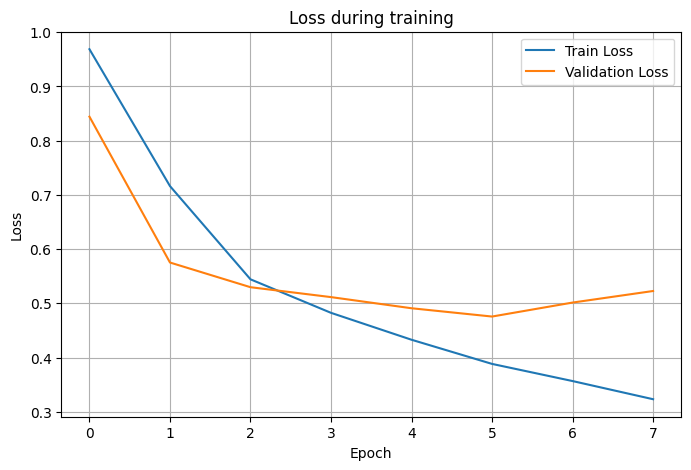

In [ ]:


plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Loss during training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


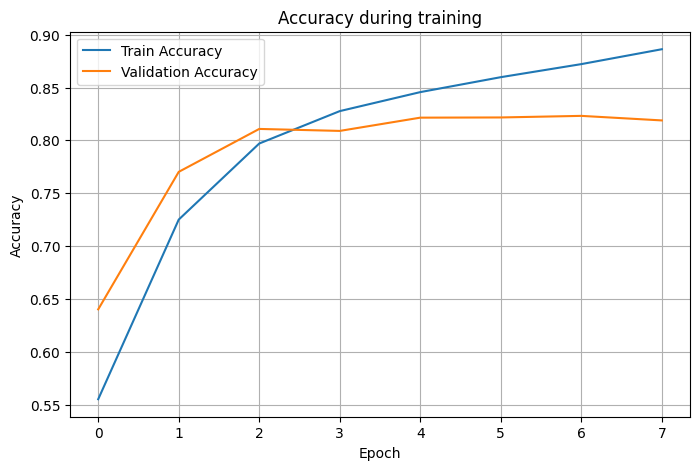

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Accuracy during training")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


Тестирование модели

In [ ]:
test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)
print("Test loss:", test_loss)
print("Test acc :", test_acc)


Test loss: 0.4878181517124176
Test acc : 0.8143712282180786


In [ ]:
y_proba = model.predict(X_test_pad, verbose=0)
y_pred = np.argmax(y_proba, axis=1)

print(classification_report(y_test, y_pred, target_names=["negative","neutral","positive"]))


              precision    recall  f1-score   support

    negative       0.85      0.86      0.85      2504
     neutral       0.56      0.41      0.47       964
    positive       0.84      0.90      0.87      3212

    accuracy                           0.81      6680
   macro avg       0.75      0.72      0.73      6680
weighted avg       0.80      0.81      0.81      6680



In [ ]:
cm = confusion_matrix(y_test, y_pred)
cm


array([[2150,  134,  220],
       [ 248,  399,  317],
       [ 136,  185, 2891]])

Визуализация матрицы ошибок

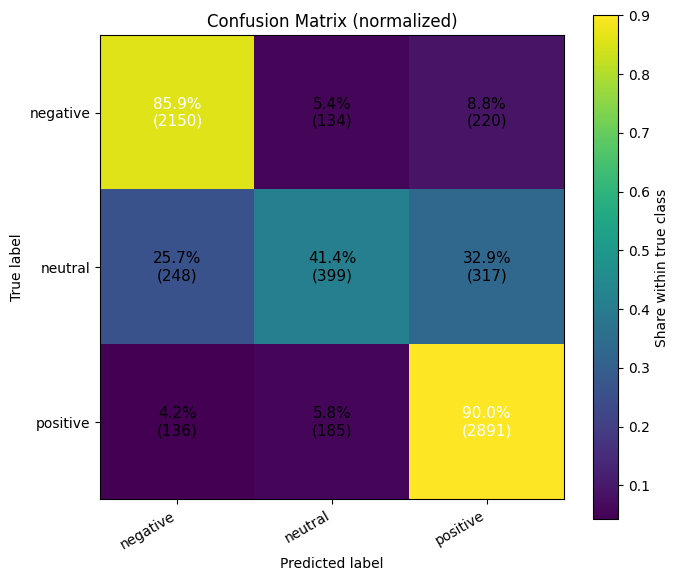

In [ ]:
labels = ["negative", "neutral", "positive"]
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_norm, interpolation="nearest")

ax.set_title("Confusion Matrix (normalized)")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_yticklabels(labels)

# Подписи внутри ячеек: процент + абсолютное значение
threshold = cm_norm.max() * 0.6
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        txt = f"{cm_norm[i, j]*100:.1f}%\n({cm[i, j]})"
        ax.text(j, i, txt, ha="center", va="center",
                color="white" if cm_norm[i, j] > threshold else "black",
                fontsize=11)

# Цветовая шкала
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Share within true class", rotation=90)

# Подписи сетки
ax.set_xlim(-0.5, len(labels) - 0.5)
ax.set_ylim(len(labels) - 0.5, -0.5)
ax.grid(False)

plt.tight_layout()
plt.show()

Общая визуализация предсказаний

In [ ]:
show_n = 10
idx = np.random.choice(len(X_test), size=show_n, replace=False)

rows = []
for i in idx:
    true = id2label[int(y_test[i])]
    pred = id2label[int(y_pred[i])]
    conf = float(np.max(y_proba[i]))
    txt = X_test[i].replace("\n", " ")
    txt = (txt[:180] + "...") if len(txt) > 180 else txt
    rows.append([txt, true, pred, conf])

pred_view = pd.DataFrame(rows, columns=["text", "true_label", "pred_label", "confidence"])
pred_view


,text,true_label,pred_label,confidence
0,Excellent,positive,positive,0.998243
1,In and out service great service,positive,positive,0.909578
2,"One car in front of me , they order big mac me...",negative,negative,0.989948
3,Love the fresh fries,positive,positive,0.987897
4,Place was dirty,negative,negative,0.731964
5,Good morning good morning the coffee was old t...,negative,negative,0.699982
6,Food was good. Service staff was clueless. Wat...,neutral,negative,0.730229
7,Fast drive through. The children enjoyed their...,positive,positive,0.959640
8,Never get anything right. I generally go to a ...,negative,negative,0.811260
9,Good food great coffee.,positive,positive,0.981036


Тест на своих фразах

In [ ]:
def predict_sentiment(texts_list):
    seq = tokenizer.texts_to_sequences(texts_list)
    pad = keras.preprocessing.sequence.pad_sequences(seq, maxlen=max_len, padding="post", truncating="post")
    proba = model.predict(pad, verbose=0)
    pred = np.argmax(proba, axis=1)
    conf = np.max(proba, axis=1)
    return [(t, id2label[int(p)], float(c)) for t, p, c in zip(texts_list, pred, conf)]

samples = [
    "The staff was rude and my order was wrong. Never coming back.",
    "It was okay, nothing special. The food is average.",
    "Fast service and everything was fresh. Great experience!"
]

predict_sentiment(samples)


[('The staff was rude and my order was wrong. Never coming back.',
  'negative',
  0.9688985347747803),
 ('It was okay, nothing special. The food is average.',
  'neutral',
  0.6627270579338074),
 ('Fast service and everything was fresh. Great experience!',
  'positive',
  0.9916940331459045)]